# Práctica guiada: aprendizaje no supervisado con Wine Clustering

En esta práctica vas a aplicar técnicas de **aprendizaje no supervisado** al dataset `wine-clustering.csv`.

## Objetivos
- Explorar un conjunto de datos sin etiquetas.
- Preparar los datos correctamente.
- Aplicar **K-Means** con distintos valores de `k`.
- Utilizar el **método del codo** y el **silhouette score**.
- Interpretar los clusters obtenidos.

> Completa las celdas y responde a las cuestiones planteadas.


## 1. Carga del dataset

Carga el archivo CSV en un DataFrame llamado `df` y muestra las primeras filas.


In [2]:
import pandas as pd

df_wines = pd.read_csv('wine-clustering.csv')
df_wines.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## 2. Primer análisis del dataset

Obtén:
- número de filas y columnas;
- tipos de datos;
- estadísticos descriptivos.

### Cuestión
¿Todas las variables son numéricas? ¿Hay diferencias importantes de escala entre unas columnas y otras?
Segun los datos mostrados en el info podemos ver que todas son numericas de tipo int o float, hay diferencias, hay columnas que están en un rango de 0 a 10, y otras de repente pasamos de 100 o de incluso 1000.

In [3]:
print(df_wines.shape)
print(df_wines.columns)

df_wines.info()

(178, 13)
Index(['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium',
       'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols',
       'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float

## 3. Preprocesamiento

Aplica un escalado con `StandardScaler`.

### Cuestión
¿Por qué es importante escalar los datos antes de aplicar K-Means?
Para que las distancias entre los puntos no sean demasiado grandes, ya que nos complicaria agrupar los datos y el modelo no necesite tanta potencia para analizar.


In [8]:
from sklearn.preprocessing import StandardScaler

# Crea una variable X con las columnas del dataset
# Después escala los datos y guarda el resultado en X_scaled

X = df_wines
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 4. Prueba distintos valores de k

Calcula la **inercia** y el **silhouette score** para valores de `k` entre 2 y 10.


In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inercias = []
silhouettes = []
valores_k = range(2, 11)

# Completa el bucle
for k in valores_k:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)
    silhouette_avg = silhouette_score(X_scaled, kmeans.labels_)
    silhouettes.append(silhouette_avg)


## 5. Representa el método del codo

Haz una gráfica de `k` frente a `inercia`.

### Cuestión
¿En qué valor de `k` parece producirse el “codo”?


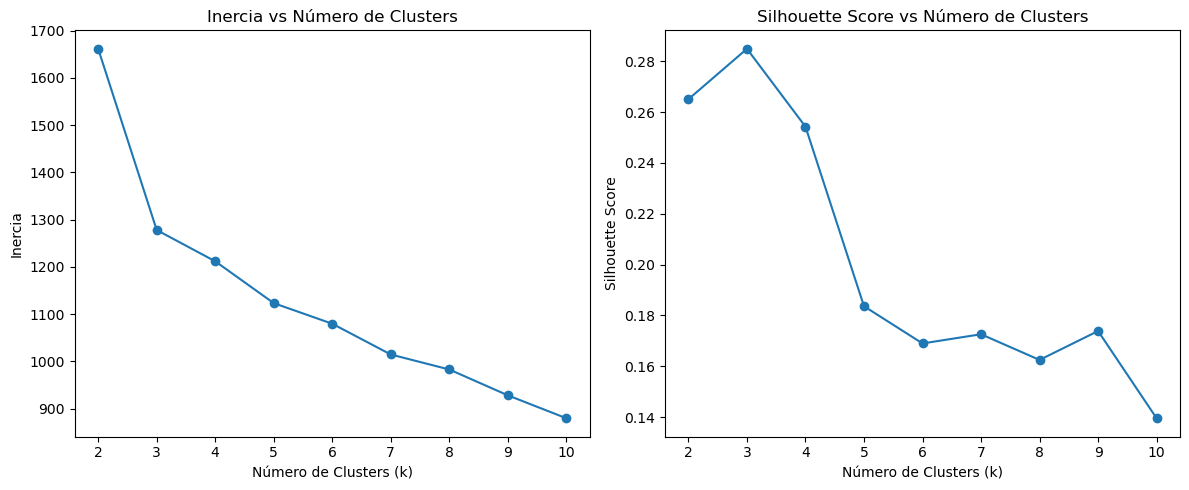

In [10]:
import matplotlib.pyplot as plt

# Escribe aquí tu código
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(valores_k, inercias, marker='o')
plt.title('Inercia vs Número de Clusters')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.subplot(1, 2, 2)
plt.plot(valores_k, silhouettes, marker='o')
plt.title('Silhouette Score vs Número de Clusters')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()


## 6. Representa el silhouette score

Haz una gráfica de `k` frente a `silhouette`.

### Cuestión
¿Qué valor de `k` obtiene el mejor resultado?
La bajada empieza a frenar en el cluster 3

In [11]:
# Escribe aquí tu código


## 7. Entrena el modelo final

Elige el valor de `k` que consideres más adecuado y entrena un modelo final de K-Means.

Guarda las etiquetas de cluster en una nueva columna llamada `cluster`.


In [ ]:
# Escribe aquí tu código
k_optimo = 3
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42)
kmeans_final.fit(X_scaled)
labels_final = kmeans_final.labels_
print(labels_final)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 2 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


## 8. Evalúa el modelo

Calcula el **silhouette score** del modelo final.

### Cuestión
¿Te parece un resultado bueno, aceptable o bajo? Razona tu respuesta.
Al dar un valor en el rango de 0 a 0.30 podemos considerar que el valor de este score no es para nada bueno, ya que los clusteres serán debiles y estarán solapados

In [ ]:
# Escribe aquí tu código del silhouette score para el modelo final
silhouette_final = silhouette_score(X_scaled, labels_final)
print(f'Silhouette Score para k={k_optimo}: {silhouette_final}')

Silhouette Score para k=3: 0.2848589191898987


## 9. Analiza el tamaño de los clusters

Cuenta cuántos registros hay en cada cluster.


In [ ]:
# Escribe aquí tu código para ver cuantos registros hay en cada cluster
import numpy as np
unique, counts = np.unique(labels_final, return_counts=True)
cluster_counts = dict(zip(unique, counts))
print(cluster_counts)

{np.int32(0): np.int64(65), np.int32(1): np.int64(51), np.int32(2): np.int64(62)}


## 10. Interpreta los clusters

Calcula la media de cada variable por cluster.

### Cuestiones
1. ¿Qué variables parecen diferenciar más unos clusters de otros?
No hay una variable especifica, sino que lo que les diferencia sobre todo es la concentración de diferentes aminoacidos, y la intensidad del color principalmente.
2. ¿Qué perfil de vino podría representar cada grupo?
Pues si tomamos los diferentes grupos de aminoacidos, no sabria decirte perfiles, pero en base a la intensidad del color podemos saber el tipo de vino que tenemos, el primer cluster son vinos de color poco intenso, vinos mas negros, el segundo un color mas promedio y el tercero ya quizás mas cerca de ser vino blanco o al menos con un tono mas rojizo, que eso se deberá a la concentración de los diferentes aminoacidos


In [ ]:
# Escribe aquí tu código para ver la media de variables por cluster
df_wines['Cluster'] = labels_final
cluster_means = df_wines.groupby('Cluster').mean()
cluster_means

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
Cluster,,,,,,,,,,,,,
0,12.250923,1.897385,2.231231,20.063077,92.738462,2.247692,2.050000,0.357692,1.624154,2.973077,1.062708,2.803385,510.169231
1,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961,1.145882,7.234706,0.691961,1.696667,619.058824
2,13.676774,1.997903,2.466290,17.462903,107.967742,2.847581,3.003226,0.292097,1.922097,5.453548,1.065484,3.163387,1100.225806


## 11. Reflexión final

Responde brevemente:

1. ¿En qué se diferencia el aprendizaje supervisado del no supervisado?
    - En que en el aprendizaje supervisado sabemos las etiquetas que tenemos para poder lograr un objetivo, pero en el no supervisado, lo que nosotros buscamos en agrupar los datos para poder darles un sentido.
2. ¿Por qué K-Means no siempre encuentra la mejor solución posible?
    - Porque los centroides de kmeans se inicializan al azar, por lo que podría dar varias soluciones diferentes al final
3. ¿Qué papel juega el preprocesamiento en este problema?
    - El escalado de los datos permite que K-means encuentre los diferentes tipos de cluster de una forma mucho mas precisa
4. ¿Qué limitaciones observas en K-Means cuando se aplica a datos reales?
    - A la hora de encontrar grupos en datos reales no sabremos cuantos vamos a tener realmente, por lo que no es algo óptimo a la hora de buscar soluciones buenas para nuestro problema.
